#**Analyzing Airbnb Booking Patterns to Improve Customer Experience & Revenue**

##**Business Understanding**

Online travel platforms like Airbnb heavily rely on understanding user behavior, booking patterns, and factors influencing customer decisions. As competition intensifies, data-driven insights become essential to improve customer experience and optimize revenue.

In this project, we analyze an Airbnb dataset to uncover booking patterns, pricing trends, and key drivers affecting listing performance

##**Problem Statement**

1. What are the key factors influencing Airbnb listing prices?
2. How does pricing affect demand, as measured by customer reviews?
3. Are there signs of inefficient pricing (overpriced or underpriced listings)?
4. How does listing quality (rating) relate to demand and performance?
5. What pricing strategies can be derived to optimize booking performance and revenue?

##**Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visual
sns.set(style='whitegrid')

In this initial step, we are importing the libraries that serve as the foundation for the data analysis project. Pandas and Numpy are used for data manipulation and numerical processing. Meanwhile, Matplotlib and Seaborn are imported for data visualization purposes. The command sns.set(style='whitegrid') is used to configure the visual theme of the plots, applying a white background with gridlines to make the charts cleaner and easier to interpret

##**Load Data**

In [2]:
df = pd.read_csv('airbnb.csv')

In [3]:
df.head()

,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,...,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...",...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...",...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...",...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...",...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...",...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm


After setting up the libraries, the next step is loading the data. Using the pd.read_csv function, an external file named 'airbnb.csv' is read and stored into a tabular structure known as a DataFrame (df). Then, the df.head() command is executed to display the first five rows of the dataset. This stage is crucial to verify that the data has been loaded correctly and to get an initial overview of the available columns, such as property names, prices, locations, and amenities

##**Data Overview**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    12805 non-null  int64  
 1   id            12805 non-null  int64  
 2   name          12805 non-null  object 
 3   rating        12805 non-null  object 
 4   reviews       12805 non-null  object 
 5   host_name     12797 non-null  object 
 6   host_id       12805 non-null  float64
 7   address       12805 non-null  object 
 8   features      12805 non-null  object 
 9   amenities     12805 non-null  object 
 10  safety_rules  12805 non-null  object 
 11  hourse_rules  12805 non-null  object 
 12  img_links     12805 non-null  object 
 13  price         12805 non-null  int64  
 14  country       12805 non-null  object 
 15  bathrooms     12805 non-null  int64  
 16  beds          12805 non-null  int64  
 17  guests        12805 non-null  int64  
 18  toiles        12805 non-nu

In [4]:
df.describe()

,Unnamed: 0,id,host_id,price,bathrooms,beds,guests,toiles,bedrooms,studios
count,12805.000000,1.280500e+04,1.280500e+04,1.280500e+04,12805.000000,12805.000000,12805.000000,12805.000000,12805.000000,12805.000000
mean,6402.000000,7.525187e+16,1.638192e+08,1.769780e+04,1.874424,3.316751,5.213745,0.019211,2.136041,0.023585
std,3696.629433,2.007933e+17,1.413622e+08,4.569364e+04,2.091399,4.037791,3.808830,0.137272,2.359005,0.151757
min,0.000000,1.313100e+04,2.303900e+04,3.930000e+02,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,3201.000000,2.023958e+07,3.700032e+07,3.994000e+03,1.000000,1.000000,2.000000,0.000000,1.000000,0.000000
50%,6402.000000,3.682229e+07,1.256459e+08,8.175000e+03,1.000000,2.000000,4.000000,0.000000,1.000000,0.000000
75%,9603.000000,4.999760e+07,2.639623e+08,1.606200e+04,2.000000,4.000000,6.000000,0.000000,3.000000,0.000000
max,12804.000000,7.017905e+17,4.758973e+08,1.907963e+06,50.000000,98.000000,16.000000,1.000000,50.000000,1.000000


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
id,0
name,0
rating,0
reviews,0
host_name,8
host_id,0
address,0
features,0
amenities,0


At this stage, an initial exploration is conducted to understand the dataset structure. This includes reviewing data types, total records, and basic statistical distributions such as mean, minimum, maximum, and quartiles.

Additionally, missing values are identified to assess data completeness and prepare for the data cleaning stage.

This step is important because it:
1. Provides an initial understanding of data quality
2. Guides preprocessing decisions
3. Prevents misinterpretation in further analysis

##**Initial Data Profiling**

In [7]:
#Mean
mean_price = df['price'].mean()

print("Mean:", mean_price)

Mean: 17697.800312377978


In [8]:
#Median
median_price = df['price'].median()

print("Median:", median_price)

Median: 8175.0


In [9]:
#Skewness
skew_price = df['price'].skew()

print("Skewness:", skew_price)

Skewness: 14.80780154890266


In [10]:
df['price'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

,price
count,1.280500e+04
mean,1.769780e+04
std,4.569364e+04
min,3.930000e+02
25%,3.994000e+03
50%,8.175000e+03
75%,1.606200e+04
90%,3.399400e+04
95%,5.905600e+04
max,1.907963e+06


The price distribution is heavily right-skewed, where the mean is significantly inflated by a small number of extremely high-priced listings. As a result, the mean is not a reliable representation of typical pricing, and the median provides a more accurate benchmark.

The initial analysis reveals the presence of extreme outliers that may distort further analysis. Therefore, proper data cleaning—especially outlier handling—is essential before proceeding to deeper insights

##**Data Cleaning**

###**Analisis Missing Value**

In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
checkout,2450
checkin,800
host_name,8
name,0
rating,0
id,0
Unnamed: 0,0
host_id,0
reviews,0
address,0


Based on the missing value analysis, most columns are complete. However, several columns contain missing values:
1. checkout (2450 entries)
2. checkin (800 entries)
3. host_name (8 entries)

Although the proportion is relatively small, proper handling is required to ensure data quality and prevent bias in further analysis, especially for variables related to user experience

###**Removing Irrelevant Column**

In [12]:
df = df.drop(columns=['Unnamed: 0', 'id'], errors='ignore')

Columns such as Unnamed: 0 and id do not contribute meaningful information for analysis, as they only serve as identifiers. Removing these columns helps simplify the dataset and reduce unnecessary noise

###**Handling Missing Values-Host Name**

In [13]:
df['host_name'] = df['host_name'].fillna('Unknown')

Missing values in the host_name column do not directly affect pricing or demand-related analysis. Instead of dropping these records, we replace missing values with "Unknown" to preserve the dataset while maintaining consistency

###**Handling Missing Values – Check-in & Check-out (Business-Oriented Approach)**

In [14]:
df['checkin'] = df['checkin'].fillna('Not Specified')
df['checkout'] = df['checkout'].fillna('Not Specified')

The checkin and checkout columns are directly related to user experience. Missing values may indicate:
1. hosts not specifying schedules
2. incomplete listing information

Instead of dropping these rows, we categorize them as "Not Specified" to retain analytical value

Listings without check-in/out info may reduce user trust and booking likelihood

###**Data Type Validation**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          12805 non-null  object 
 1   rating        12805 non-null  object 
 2   reviews       12805 non-null  object 
 3   host_name     12805 non-null  object 
 4   host_id       12805 non-null  float64
 5   address       12805 non-null  object 
 6   features      12805 non-null  object 
 7   amenities     12805 non-null  object 
 8   safety_rules  12805 non-null  object 
 9   hourse_rules  12805 non-null  object 
 10  img_links     12805 non-null  object 
 11  price         12805 non-null  int64  
 12  country       12805 non-null  object 
 13  bathrooms     12805 non-null  int64  
 14  beds          12805 non-null  int64  
 15  guests        12805 non-null  int64  
 16  toiles        12805 non-null  int64  
 17  bedrooms      12805 non-null  int64  
 18  studios       12805 non-nu

In [16]:
# Fix incorrect data types
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['reviews'] = pd.to_numeric(df['reviews'], errors='coerce')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          12805 non-null  object 
 1   rating        8567 non-null   float64
 2   reviews       12804 non-null  float64
 3   host_name     12805 non-null  object 
 4   host_id       12805 non-null  float64
 5   address       12805 non-null  object 
 6   features      12805 non-null  object 
 7   amenities     12805 non-null  object 
 8   safety_rules  12805 non-null  object 
 9   hourse_rules  12805 non-null  object 
 10  img_links     12805 non-null  object 
 11  price         12805 non-null  int64  
 12  country       12805 non-null  object 
 13  bathrooms     12805 non-null  int64  
 14  beds          12805 non-null  int64  
 15  guests        12805 non-null  int64  
 16  toiles        12805 non-null  int64  
 17  bedrooms      12805 non-null  int64  
 18  studios       12805 non-nu

During data type validation, it was identified that several columns such as rating and reviews were incorrectly stored as object types instead of numeric. This issue may arise due to inconsistent data entry or formatting.

To ensure accurate analysis, these columns were converted into numeric format using type coercion, allowing proper statistical calculations and correlation analysis.

###**Data Duplication and Removal**

In [18]:
df.duplicated().sum()

np.int64(1)

In [19]:
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

Duplicate records can introduce bias in statistical calculations such as averages, distributions, and correlations. Therefore, all duplicate rows are removed to maintain data integrity

###**Outlier Handling (Critical Step Based on Initial Findings)**

In [21]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

df = df[df['price'] < upper_bound]

In [22]:
print(df['price'].describe())

count    11531.000000
mean      9274.627352
std       7370.210387
min        393.000000
25%       3641.000000
50%       7248.000000
75%      12785.500000
max      34151.000000
Name: price, dtype: float64


From the initial data profiling, the price distribution was found to be highly right-skewed, with extreme outliers reaching values far beyond the typical range.

These outliers can:
1. Distort average values
2. Bias analytical insights
3. Lead to incorrect pricing strategies

To address this, we apply the Interquartile Range (IQR) method, a robust statistical approach for outlier detection and removal

By removing extreme values, the analysis becomes more representative of the core market segment rather than being dominated by a small number of ultra-premium listings

###**Validation After Cleaning**

In [23]:
df.describe()

,rating,reviews,host_id,price,bathrooms,beds,guests,toiles,bedrooms,studios
count,7965.000000,11530.000000,1.153100e+04,11531.000000,11531.000000,11531.000000,11531.000000,11531.000000,11531.000000,11531.000000
mean,4.855046,38.216132,1.662600e+08,9274.627352,1.580002,2.907033,4.683549,0.020900,1.825427,0.025930
std,0.139840,67.655479,1.411390e+08,7370.210387,1.621809,3.489202,3.332021,0.143056,1.960662,0.158934
min,3.250000,0.000000,2.303900e+04,393.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,4.770000,1.000000,3.986570e+07,3641.000000,1.000000,1.000000,2.000000,0.000000,1.000000,0.000000
50%,4.890000,12.000000,1.295166e+08,7248.000000,1.000000,2.000000,4.000000,0.000000,1.000000,0.000000
75%,4.980000,45.000000,2.659272e+08,12785.500000,2.000000,3.000000,6.000000,0.000000,2.000000,0.000000
max,5.000000,943.000000,4.758973e+08,34151.000000,50.000000,98.000000,16.000000,1.000000,50.000000,1.000000


After completing the data cleaning process, we re-evaluate the dataset to ensure that the distribution is more stable and no longer heavily influenced by extreme values.

This step confirms that the dataset is ready for further exploratory analysis and business insight generation

##**Exploratiry Data Analyst**

###**Visual Setup**

In [24]:
soft_palette1 = ["#A8DADC", "#B5EAD7", "#CDB4DB"]
soft_palette2 = ["#FFDDD2", "#FEC5BB", "#E2ECE9"]
soft_palette3 = ["#D8E2DC", "#FFE5D9", "#BDE0FE"]

###**Factors Influencing Prices**

####**Factor 1**

In [29]:
df['bedroom_group'] = pd.cut(
    df['bedrooms'],
    bins=[0, 1, 3, 6, 50],
    labels=['Studio/1', '2-3', '4-6', '7+']
)

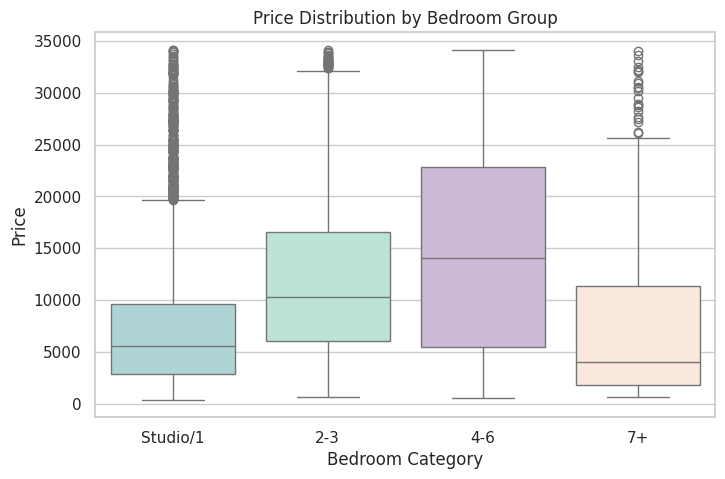

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x='bedroom_group', y='price', data=df,
            palette=["#A8DADC", "#B5EAD7", "#CDB4DB", "#FFE5D9"])

plt.title("Price Distribution by Bedroom Group")
plt.xlabel("Bedroom Category")
plt.ylabel("Price")

plt.show()

####**Factor 2**

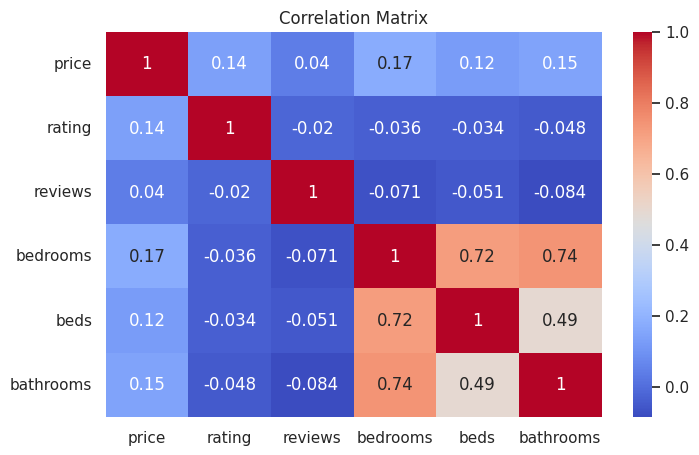

In [31]:
plt.figure(figsize=(8,5))

corr = df[['price', 'rating', 'reviews', 'bedrooms', 'beds', 'bathrooms']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

####**Factor 3**

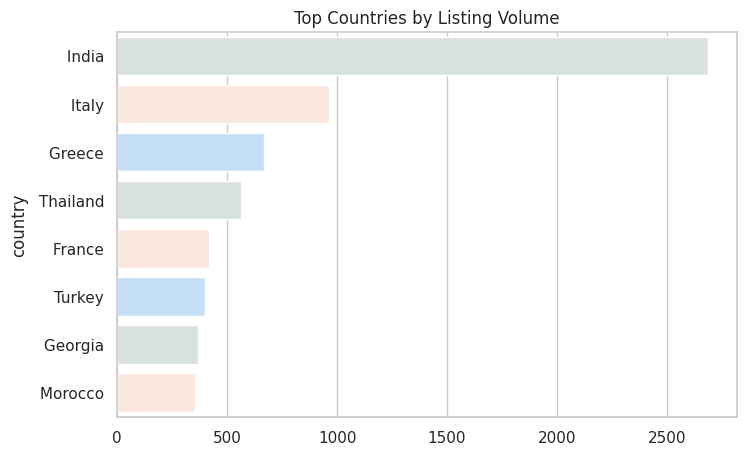

In [36]:
top_country = df['country'].value_counts().head(8)

plt.figure(figsize=(8,5))

sns.barplot(x=top_country.values, y=top_country.index, palette=soft_palette3)

plt.title("Top Countries by Listing Volume")
plt.show()

The analysis explores the key factors influencing Airbnb listing prices by examining property characteristics and location-based distribution.

From the boxplot, it is evident that property size, represented by the number of bedrooms, plays a significant role in determining prices. Listings with more bedrooms generally show higher median prices, indicating that larger properties are typically priced higher. However, there is substantial overlap between categories, suggesting that smaller listings can sometimes be priced similarly to larger ones.

This observation is reinforced by the correlation analysis, where structural features such as bedrooms (0.17), bathrooms (0.15), and beds (0.12) show positive but relatively weak correlations with price. This indicates that while these factors contribute to pricing, they are not strong standalone drivers.

In addition, the distribution of listings across countries reveals that supply is heavily concentrated in certain regions, with countries like India dominating the dataset. This suggests that location plays an indirect but important role, as market competition and regional demand dynamics may influence how listings are priced

###**Price vs Demand (Reviews as Proxy)**

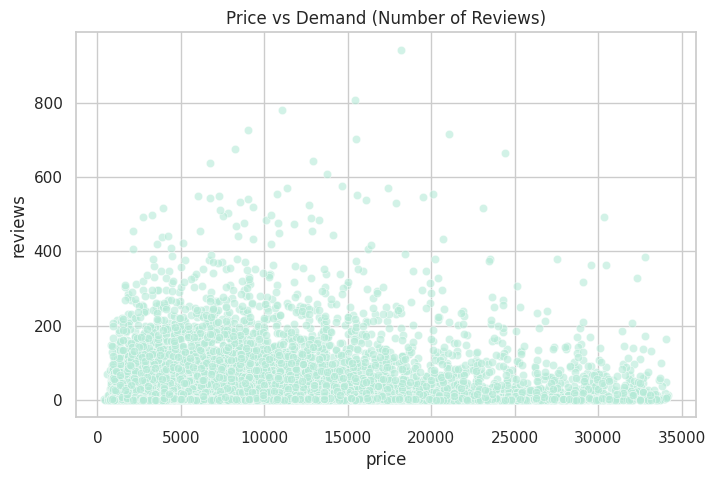

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='price', y='reviews', data=df,
                color="#B5EAD7", alpha=0.6)

plt.title("Price vs Demand (Number of Reviews)")
plt.show()

The scatter plot illustrates the relationship between listing price and demand, using the number of reviews as a proxy for customer interest and booking frequency.

From the visualization, a clear pattern emerges where listings with lower prices tend to accumulate more reviews, while higher-priced listings generally receive fewer reviews. This indicates a negative relationship between price and demand, where increasing prices may reduce booking activity.

Additionally, the distribution shows that high-demand listings are heavily concentrated in the lower to mid-price range, while expensive listings are more sparsely populated and often associated with lower review counts. This suggests that only a small portion of high-priced listings successfully attract significant demand

###**Pricing Efficiency (Overpriced vs Underpriced)**

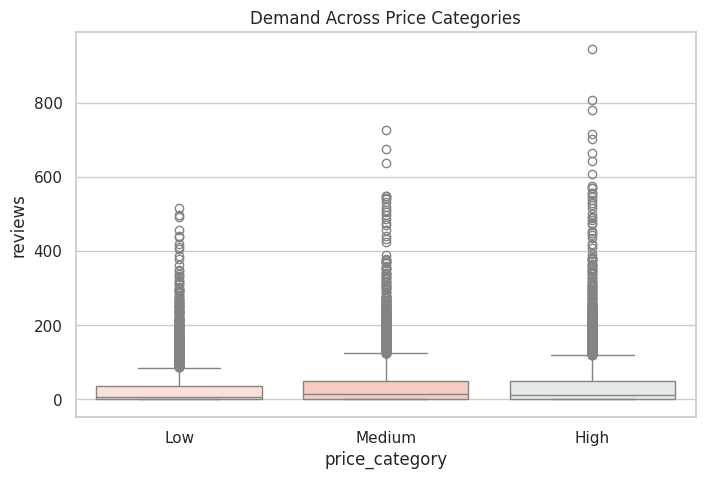

In [33]:
df['price_category'] = pd.qcut(df['price'], 3, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(8,5))

sns.boxplot(x='price_category', y='reviews', data=df, palette=soft_palette2)

plt.title("Demand Across Price Categories")
plt.show()

The boxplot compares demand across different price categories (Low, Medium, High), using the number of reviews as a proxy for booking activity.

From the visualization, we observe that listings in the Low price category tend to have relatively higher and more consistent review counts, indicating stronger and more stable demand. In contrast, Medium and High price categories show greater variability, with many listings receiving low reviews and only a few achieving high demand.

Interestingly, while some high-priced listings do reach high review counts, they are outliers rather than the norm. This suggests that only a small subset of premium listings successfully justify their higher prices, likely due to factors such as superior location, amenities, or brand perception

###**Rating vs Listing Performance**

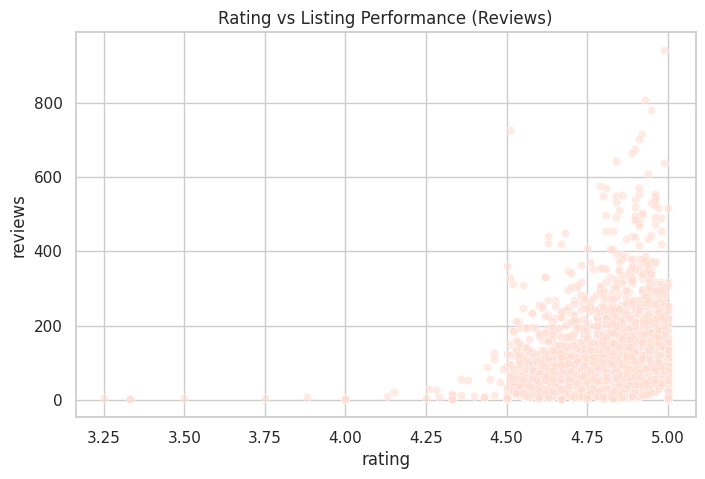

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='rating', y='reviews', data=df,
                color="#FFDDD2", alpha=0.6)

plt.title("Rating vs Listing Performance (Reviews)")
plt.show()

Since availability data is not present in the dataset, listing performance is analyzed using rating as a proxy for quality and reviews as a proxy for demand.

The scatter plot shows that listings with higher ratings tend to achieve slightly higher review counts, although the relationship is not strongly linear. Many listings with high ratings still receive relatively low reviews, indicating that rating alone is not sufficient to drive demand.

###**Pricing Strategy to Optimize Performance & Revenue**

In [39]:
df['revenue_proxy'] = df['price'] * df['reviews']

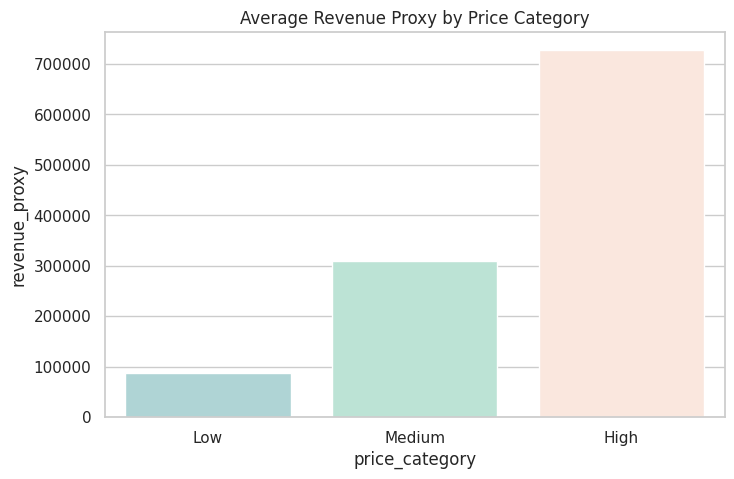

In [41]:
avg_revenue = df.groupby('price_category')['revenue_proxy'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(x='price_category', y='revenue_proxy', data=avg_revenue,
            palette=["#A8DADC", "#B5EAD7", "#FFE5D9"])

plt.title("Average Revenue Proxy by Price Category")
plt.show()

The bar chart illustrates the average revenue proxy across different price categories, where revenue is estimated using the product of price and number of reviews.

From the visualization, it is evident that high-priced listings generate the highest average revenue, followed by medium and low price categories. This suggests that, despite having lower demand (fewer reviews), the significantly higher price of premium listings is able to compensate and drive overall revenue upward.

However, this pattern should be interpreted with caution. The higher average revenue in the high-price category may be influenced by a smaller number of listings with exceptionally high prices or strong performance, rather than representing consistent performance across all listings

###**Final Insight**

1. Pricing is influenced by multiple factors, not just property size
While bedrooms, beds, and bathrooms show a positive relationship with price, the correlations are relatively weak, indicating that pricing decisions are multi-dimensional and likely influenced by additional factors such as location, competition, and perceived value
2. Demand is highly price-sensitive
Lower-priced listings tend to attract significantly more reviews, suggesting that customers are more responsive to affordable pricing and that demand is concentrated in the low-to-mid price range.
3. Pricing inefficiency exists across the market
Many high-priced listings underperform in terms of demand, while lower-priced listings often generate consistent engagement, indicating the presence of both overpriced and underpriced listings.
4. Listing quality (rating) alone does not guarantee performance
Although higher ratings contribute to credibility, they show weak correlation with demand, meaning that factors such as pricing and visibility play a more critical role in driving bookings.
Revenue optimization requires balancing price and demand
5. High-priced listings can generate the highest revenue on average, but performance is inconsistent. This highlights that maximizing revenue is not about setting the highest price, but about finding the optimal balance between price and demand

###**Business Recommendation**

1. Implement Demand-Based Pricing Strategy.
Adjust pricing dynamically based on demand signals (e.g., number of reviews).
*   Increase prices for high-demand listings
*   Reduce prices for underperforming listings




2. Optimize Mid-Tier Pricing Segment. Focus on the mid-price range where demand and revenue potential are more balanced and stable.
*   Avoid extreme pricing without strong differentiation



3. Identify and Correct Pricing Inefficiencies
*   Overpriced listings: High price + low reviews → consider price reduction
*   Underpriced listings: Low price + high reviews → opportunity to increase price



4. Enhance Value for Premium Pricing. High prices should be supported by strong value propositions:
*   Better Aminities
*   Strategic Location
*   Unique Experience
Without these, premium pricing may lead to low demand




5. Do Not Rely Solely on Ratings. Although ratings are important for trust, they are not strong drivers of demand.
*   Combine rating improvements with pricing optimization
*   Focus on visibility and competitiveness



###**Conlusion**

This analysis explores the key drivers of Airbnb listing performance by examining the relationship between price, demand, property characteristics, and perceived quality.

The findings reveal that pricing is not determined by a single factor, but rather by a combination of structural attributes, market dynamics, and strategic positioning. While larger properties tend to command higher prices, the relatively weak correlations indicate that property size alone is not a strong predictor. This suggests that hosts consider multiple elements—such as competition, location, and perceived value—when setting prices.

From a demand perspective, the analysis shows that customer behavior is highly price-sensitive. Listings in the lower to mid-price range consistently attract more reviews, indicating higher booking activity. In contrast, higher-priced listings often experience lower demand, with only a small subset achieving strong performance. This highlights the presence of pricing inefficiencies, where some listings may be overpriced or underpriced relative to market expectations.

Interestingly, listing quality—measured by rating—does not exhibit a strong relationship with demand. This suggests that while ratings contribute to credibility, they are not sufficient to drive booking performance on their own. Instead, pricing remains a more dominant factor influencing customer decisions.

When examining revenue potential, premium-priced listings show the highest average returns. However, this comes with higher variability and risk, as not all high-priced listings perform well. This reinforces the idea that revenue optimization is not achieved by maximizing price alone, but by balancing price with demand.

Overall, the analysis emphasizes that successful pricing strategies in the Airbnb market require a multi-dimensional approach. Hosts must align pricing with demand patterns, competitive positioning, and value delivery to achieve optimal performance

###**Business Implication**

To remain competitive, hosts and platforms should adopt data-driven pricing strategies that:
1. Continuously adjust to demand signals
2. Address pricing inefficiencies
3. Balance affordability with revenue goals
4. Support premium pricing with clear value differentiation

By doing so, they can improve booking performance while sustaining long-term revenue growth.